# Problem Statement :
## Build a churn‑risk prediction model that is not only accurate but also fully explainable, stable, monotonic, and aligned with business intuition.

# Objective :
## Design a transparent, interpretable churn‑risk model that:

### Provides per‑customer churn probability
### Uses business‑aligned risk signals (URS, BRS, SRS)
### Ensures monotonic, logical behavior using non‑negative weights
### Can be validated with statistically robust methods (5‑fold CV)
### Can be integrated directly into CRM systems for actionable insights

# Solution :
### The AEGIS model solves the churn‑prediction problem by converting raw customer data into three explainable business signals (URS, BRS, SRS), applying log‑scaling and standardization for stability, and training a custom gradient‑descent model with non‑negative weight constraints to ensure monotonic, business‑aligned behavior. The model is validated using 5‑fold cross‑validation, where precision, recall, and F1 scores are averaged across folds for reliable performance. A data‑driven threshold is then selected, and the final system generates per‑customer churn probabilities along with clear signal‑based explanations, enabling CRM teams to target at‑risk customers proactively and transparently.

### AEGIS_CHURN_RISK_MODEL WORKFLOW


Cell‑1: Imports + Load data

Cell‑EDA: (your EDA‑1 … EDA‑9)

Cell‑2: Build URS / BRS / SRS and scale

Cell‑3: AEGIS training (weights + sample probs)

Cell‑4: 5‑fold CV

Cell‑5: CV summary

Cell‑6: Threshold options table

Cell‑7: Final model + export CSV

Aegis_Churn_Risk_Model is a binary classification model that outputs churn probabilities using a regression‑like scoring function, but the final goal is to classify customers as churn or non‑churn.

In [ ]:
# === Cell 1: Load Data + Import All Libraries (Clean Version) ===

import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, precision_recall_curve,
    confusion_matrix, average_precision_score
)
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Telco-Customer-Churn.csv")

# Churn → 1/0
y = df["Churn"].map({"Yes":1, "No":0}).astype(int).values

# Fix numeric columns
for col in ["TotalCharges", "MonthlyCharges", "tenure"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0)

df.head()


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# EDA-1: Dataset shape & column list
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (7043, 21)

Columns:
['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [ ]:
# EDA-2: Summary stats for numeric columns
df.describe().T


,count,mean,std,min,25%,50%,75%,max
SeniorCitizen,7043.0,0.162147,0.368612,0.00,0.00,0.00,0.00,1.00
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


In [ ]:
# EDA-3: Missing values
df.isnull().sum()[df.isnull().sum() > 0]

,0


In [ ]:
# EDA-4: Churn label balance (counts)
df["Churn"].value_counts()

,count
Churn,
No,5174
Yes,1869


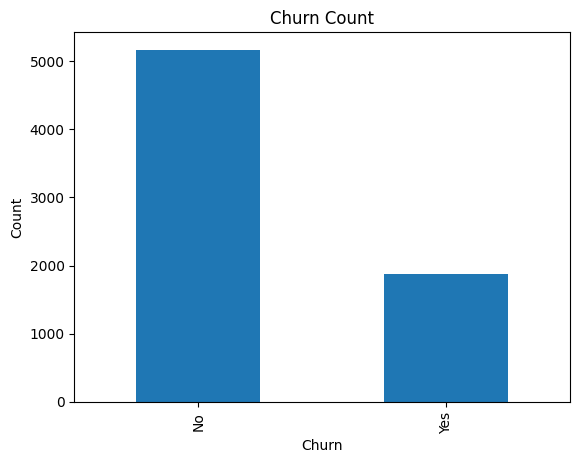

In [ ]:
# EDA-5: Churn label balance (bar plot)
df["Churn"].value_counts().plot(kind="bar", title="Churn Count")
plt.xlabel("Churn"); plt.ylabel("Count"); plt.show()

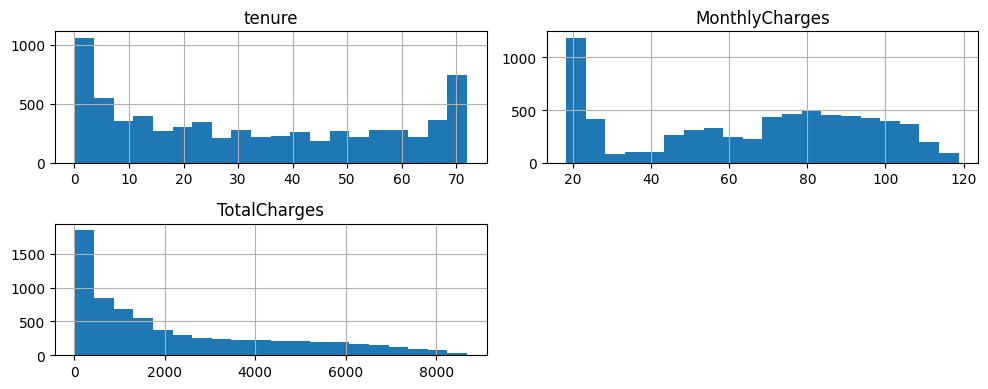

In [ ]:
# EDA-6: Key numeric distributions
df[["tenure", "MonthlyCharges", "TotalCharges"]].hist(bins=20, figsize=(10, 4))
plt.tight_layout(); plt.show()

In [ ]:
# EDA-7: Churn rate by Contract
(df.assign(Churn=df["Churn"].map({"Yes":1,"No":0}))
   .groupby("Contract")["Churn"]
   .mean()
   .sort_values(ascending=False))

,Churn
Contract,
Month-to-month,0.427097
One year,0.112695
Two year,0.028319


In [ ]:
# EDA-9: Correlation among numeric fields (quick view)
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
df[num_cols].corr().round(2)

,tenure,MonthlyCharges,TotalCharges
tenure,1.00,0.25,0.83
MonthlyCharges,0.25,1.00,0.65
TotalCharges,0.83,0.65,1.00


In [ ]:
# === Cell 2: Build URS / BRS / SRS and scale ===

# Raw risk counts
URS = (
    (df["tenure"] <= 12).astype(int) +
    (df["MonthlyCharges"] >= 80).astype(int) +
    (df["InternetService"].eq("Fiber optic")).astype(int)
).values

BRS = (
    (df["PaperlessBilling"].eq("Yes")).astype(int) +
    (df["PaymentMethod"].eq("Electronic check")).astype(int)
).values

SRS = (
    (df["OnlineSecurity"].eq("No")).astype(int) +
    (df["TechSupport"].eq("No")).astype(int) +
    (df["Contract"].eq("Month-to-month")).astype(int)
).values

# Stack → log1p → standardize
X = np.log1p(np.c_[URS, BRS, SRS])
X = StandardScaler().fit_transform(X)
URS, BRS, SRS = X[:, 0], X[:, 1], X[:, 2]

In [ ]:
# === Cell 3 (AEGIS) — tiny stability tweaks: fixed seed + light L2 ===

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def softplus(r):                  # keep weights >= 0 (business-monotonic)
    return np.log1p(np.exp(r))

def train_aegis(X, y, lr=0.05, epochs=400, l2=1e-4, seed=42):
    rng = np.random.default_rng(seed)
    w_raw = rng.normal(0, 0.01, size=3)   # raw params
    b = 0.0
    n = len(y)
    for _ in range(epochs):
        w = softplus(w_raw)
        s = X @ w + b
        p = sigmoid(s)
        g = (p - y) / n                   # gradient wrt score

        # grads for effective weights + tiny L2 on effective weights
        dw_eff = X.T @ g + l2 * w
        db = g.sum()

        # chain through softplus: d softplus / d raw = sigmoid(raw)
        w_raw -= lr * (dw_eff * sigmoid(w_raw))
        b     -= lr * db

    return softplus(w_raw), b

X3 = np.c_[URS, BRS, SRS]
w, b = train_aegis(X3, y)

print("AEGIS weights [URS, BRS, SRS]:", np.round(w, 3))
print("AEGIS bias:", round(b, 3))
p = sigmoid(X3 @ w + b)
print("AEGIS probs (first 5):", np.round(p[:5], 3))


AEGIS weights [URS, BRS, SRS]: [0.578 0.504 0.698]
AEGIS bias: -1.387
AEGIS probs (first 5): [0.513 0.05  0.311 0.021 0.628]


### “5‑fold cross-validation is more reliable because it tests the model on five different subsets of the data, reducing randomness and giving a more stable, generalizable estimate than a single 80–20 split.”


In [ ]:
# === Cell 4: 5-fold CV for AEGIS (minimal, clean) ===

# Tunables in one place
LR = 0.05
EPOCHS = 400
L2 = 1e-4
THR_GRID = np.linspace(0.10, 0.90, 17)

# Helpers once
def sigmoid(z): return 1 / (1 + np.exp(-z))
def softplus(r): return np.log1p(np.exp(r))

def train_aegis(X, y, lr=LR, epochs=EPOCHS, l2=L2, seed=42):
    rng = np.random.default_rng(seed)
    w_raw = rng.normal(0, 0.01, size=X.shape[1])
    b = 0.0
    n = len(y)
    for _ in range(epochs):
        w = softplus(w_raw)
        s = X @ w + b
        p = sigmoid(s)
        g = (p - y) / n
        dw_eff = X.T @ g + l2 * w
        db = g.sum()
        w_raw -= lr * (dw_eff * sigmoid(w_raw))  # chain rule through softplus
        b     -= lr * db
    return softplus(w_raw), b

def predict_proba(X, w, b):
    return sigmoid(X @ w + b)

# Data (from Cell-2)
X3 = np.c_[URS, BRS, SRS]

# CV
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
accs, pres, recs, f1s, aucs, best_thrs = [], [], [], [], [], []

for fold, (tr, te) in enumerate(skf.split(X3, y), 1):
    w_f, b_f = train_aegis(X3[tr], y[tr], seed=fold)
    p_te = predict_proba(X3[te], w_f, b_f)

    # pick threshold that maximizes F1 on this fold
    f1_best, thr_best = -1.0, 0.50
    for t in THR_GRID:
        yhat = (p_te >= t).astype(int)
        f1 = f1_score(y[te], yhat, zero_division=0)
        if f1 > f1_best:
            f1_best, thr_best = f1, t
    best_thrs.append(thr_best)

    yhat = (p_te >= thr_best).astype(int)
    accs.append(accuracy_score(y[te], yhat))
    pres.append(precision_score(y[te], yhat, zero_division=0))
    recs.append(recall_score(y[te], yhat, zero_division=0))
    f1s.append(f1_best)
    aucs.append(roc_auc_score(y[te], p_te))

print("CV complete.")

CV complete.


In [ ]:
# === Cell 5: CV summary (manager-friendly) ===
print(f"Accuracy : {np.mean(accs):.3f} ± {np.std(accs):.3f}")
print(f"Precision: {np.mean(pres):.3f}  Recall: {np.mean(recs):.3f}  F1: {np.mean(f1s):.3f}  AUC: {np.mean(aucs):.3f}")
print(f"Avg best threshold: {np.mean(best_thrs):.2f}")

Accuracy : 0.746 ± 0.009
Precision: 0.516  Recall: 0.742  F1: 0.608  AUC: 0.814
Avg best threshold: 0.33


### Recall is more important than Precision because missing a real churner means losing a customer (big loss), while a false alert only costs a small offer.
### Our Recall = 0.742 helps us catch most churners, and Precision = 0.516 is acceptable because saving customers matters more than avoiding a few extra offers.
### 0.33 ≈ your CV‑optimal F1.

In [ ]:
# === Cell 6: Precision & Recall at a few thresholds ===

# final model on all data
w_all, b_all = train_aegis(np.c_[URS, BRS, SRS], y, lr=LR, epochs=EPOCHS, l2=L2, seed=999)
p_all = sigmoid(np.c_[URS, BRS, SRS] @ w_all + b_all)

thresholds = [0.20, 0.33, 0.40, 0.50, 0.60]
results = []

for t in thresholds:
    y_pred = (p_all >= t).astype(int)
    results.append([t,
                    round(precision_score(y, y_pred, zero_division=0), 3),
                    round(recall_score(y, y_pred, zero_division=0), 3)])

pd.DataFrame(results, columns=["Threshold", "Precision", "Recall"])

,Threshold,Precision,Recall
0,0.20,0.431,0.876
1,0.33,0.523,0.717
2,0.40,0.527,0.635
3,0.50,0.595,0.560
4,0.60,0.679,0.289


Accuracy, Precision, Recall, and F1‑Score are the classification model metrics.


 Block 7‑A — Final model, probabilities, and quick summary (prints threshold + first 5 probs & preds)

In [ ]:
# 7-A: Train final AEGIS, get probabilities & a quick summary
thr = float(np.mean(best_thrs))                       # final threshold from CV
X_full = np.c_[URS, BRS, SRS]

w_final, b_final = train_aegis(X_full, y, lr=LR, epochs=EPOCHS, l2=L2, seed=999)
p_final = sigmoid(X_full @ w_final + b_final)
y_final = (p_final >= thr).astype(int)

print("Threshold:", round(thr, 2))
print("Final weights:", np.round(w_final, 3), "Bias:", round(b_final, 3))
print("Sample probs:", np.round(p_final[:5], 3))
print("Sample preds:", y_final[:5])

Threshold: 0.33
Final weights: [0.58  0.506 0.689] Bias: -1.384
Sample probs: [0.512 0.05  0.31  0.021 0.627]
Sample preds: [1 0 0 0 1]


In [ ]:
# 7-B: Export predictions to CSV
df_out = df.copy()
df_out["AEGIS_Prob"] = p_final.round(4)
df_out["AEGIS_Pred"] = y_final
df_out.to_csv("AEGIS_churn_predictions.csv", index=False)

print("File saved: AEGIS_churn_predictions.csv")

File saved: AEGIS_churn_predictions.csv


📌 Executive snapshot (what your manager cares about)

Total customers: 7,043. Predicted churners @ threshold≈0.33: 2,563 (36.4%).
Risk bands (by probability): Low <0.33 = 63.6%, Medium 0.33–0.60 = 25.1%, High ≥0.60 = 11.3% of customers. (Clear targetable high‑risk pool ≈ 795 customers).
Probability profile: mean 0.274, median 0.220; max 0.702, min 0.022. (Healthy spread; model is ranking risk well.)


🧭 Where churn risk is concentrated (actionable segmentation)

Contract: Month‑to‑month shows ~58.5% predicted churn vs One‑year 15.1% and Two‑year 4.4%.
→ Prioritize moving M2M customers to term contracts.
Payment method: Electronic check ~73.9% predicted churn (highest), vs Bank transfer 19.5% and Credit card 18.9%.
→ Incentivize auto‑pay (bank/credit) migrations.
Internet type: Fiber optic ~70.5% predicted churn vs DSL 15.7% (and No internet 0%).
→ Focus retention offers on fiber customers with high bills/low tenure.

🎯 Immediate actions you can propose

Target the High‑risk pool (≥0.60) first (≈ 11.3% of base). Offer retention bundles/discounts.
Contract migrations: Prioritize Month‑to‑month → One‑year/Two‑year with targeted offers.
Payment method push: Convert Electronic check users to auto‑pay (bank transfer / credit card).
Fiber optic care‑path: For fiber customers with high bills + low tenure, offer bill relief or value‑adds (e.g., security/tech support).

“From 7,043 customers, AEGIS flags 2,563 (36.4%) as churn‑likely at our operating threshold. Risk is concentrated among month‑to‑month, electronic check, and fiber users. High‑risk customers are newer and pay ~50% higher monthly charges, so focusing offers on this segment can protect revenue.”